# Comparación de Redes Metabólicas: Sano vs. Enfermo

Análisis comparativo de las propiedades topológicas de dos redes de rutas metabólicas reconstruidas a partir de datos metagenómicos:

- **Red sana (`H_adjcent_path_completeNET.csv`)**: individuos sanos
- **Red enferma (`DD_adjcent_path_completeNET.csv`)**: individuos enfermos

**Contenido del análisis:**
1. Carga y binarización de matrices de adyacencia
2. Construcción de grafos con NetworkX
3. Resumen topológico comparativo
4. Análisis diferencial: aristas ganadas, perdidas y conservadas
5. Visualizaciones de distribución de grados y red diferencial
6. Pruebas estadísticas no paramétricas (KS, Mann-Whitney, Wilcoxon)
7. Prueba de permutación

## 1. Importaciones

In [27]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import ks_2samp, mannwhitneyu, wilcoxon
from statsmodels.distributions.empirical_distribution import ECDF

## 2. Carga de Datos

Se cargan las matrices de adyacencia de ambas redes y se convierten a matrices **binarias** (1 = arista presente, 0 = ausente).

In [28]:
A_healthy = pd.read_csv("H_adjcent_path_completeNET.csv", index_col=0)
A_disease  = pd.read_csv("DD_adjcent_path_completeNET.csv", index_col=0)

A_healthy = (A_healthy > 0).astype(int)
A_disease  = (A_disease  > 0).astype(int)

print(f"Healthy matrix shape : {A_healthy.shape}")
print(f"Disease matrix shape : {A_disease.shape}")

Healthy matrix shape : (619, 619)
Disease matrix shape : (619, 619)


## 3. Construcción de Grafos

Se alinean ambas matrices al mismo conjunto de nodos y se construyen los grafos con NetworkX.

In [29]:
# Se alinenan las matrices
nodes = sorted(set(A_healthy.index) | set(A_disease.index))

A_healthy = A_healthy.reindex(index=nodes, columns=nodes, fill_value=0)
A_disease  = A_disease.reindex(index=nodes,  columns=nodes,  fill_value=0)

G_healthy = nx.from_pandas_adjacency(A_healthy)
G_disease  = nx.from_pandas_adjacency(A_disease)

print(f"Shared node set : {len(nodes)} nodes")

Shared node set : 619 nodes


## 4. Resumen Topológico

Métricas globales de cada red: densidad, grado promedio, clustering, componentes conectadas y tamaño del componente más grande.

In [30]:
def network_summary(G, name):
    components = list(nx.connected_components(G))
    lcc = max(len(c) for c in components)
    asp = (
        nx.average_shortest_path_length(G)
        if nx.is_connected(G)
        else np.nan
    )
    return {
        "Network":              name,
        "Nodes":                G.number_of_nodes(),
        "Edges":                G.number_of_edges(),
        "Density":              round(nx.density(G), 6),
        "Avg Degree":           round(np.mean([d for _, d in G.degree()]), 4),
        "Avg Clustering":       round(nx.average_clustering(G), 6),
        "Components":           len(components),
        "Largest Component":    lcc,
        "Avg Shortest Path":    asp,
    }


summary_df = pd.DataFrame([
    network_summary(G_healthy, "Healthy"),
    network_summary(G_disease,  "Disease"),
])
print("Reporte topologico")
summary_df.to_csv("network_topology_summary.csv", index=False)
summary_df

Reporte topologico


,Network,Nodes,Edges,Density,Avg Degree,Avg Clustering,Components,Largest Component,Avg Shortest Path
0,Healthy,619,876,0.004580,2.8304,0.303883,388,51,NaN
1,Disease,619,1215,0.006352,3.9257,0.307501,377,66,NaN


## 4. Análisis Diferencial

Identificación de aristas **ganadas**, **perdidas** y **conservadas** al pasar del estado sano al enfermo, y cuantificación del cambio de grado por nodo.

In [31]:
Delta     = A_disease - A_healthy
Gained    = (Delta ==  1)
Lost      = (Delta == -1)
Conserved = (A_healthy == 1) & (A_disease == 1)

# Dividimos porque estamos usando un grafo no dirigido
n_gained    = Gained.values.sum()    // 2
n_lost      = Lost.values.sum()      // 2
n_conserved = Conserved.values.sum() // 2

Delta.to_csv("differential_adjacency.csv")

edge_summary = pd.DataFrame({
    "Category": ["Gained in disease", "Lost in disease", "Conserved"],
    "Edges":    [n_gained, n_lost, n_conserved],
})
print(edge_summary.to_string(index=False))

         Category  Edges
Gained in disease    609
  Lost in disease    270
        Conserved    606


In [32]:
degree_change = pd.DataFrame({
    "degree_healthy": pd.Series(dict(G_healthy.degree())),
    "degree_disease":  pd.Series(dict(G_disease.degree())),
})
degree_change["delta_degree"] = (
    degree_change["degree_disease"] - degree_change["degree_healthy"]
)
degree_change = degree_change.sort_values("delta_degree", ascending=False)
degree_change.to_csv("degree_change.csv")

print("Top 10 — nodos que ganan mas conecciones en la enfermedad:")
print(degree_change.head(10))
print("\nTop 10 — nodos que pierden mas conecciones en la enfermedad:")
print(degree_change.tail(10))

Top 10 — nodos que ganan mas conecciones en la enfermedad:
          degree_healthy  degree_disease  delta_degree
PWY-7277               0              31            31
PWY-7433               0              31            31
PWY-7112               0              31            31
PWY-7185               0              31            31
PWY-7426               0              31            31
PWY-7434               0              31            31
PWY-6564               0              31            31
PWY-6569               0              31            31
PWY-6861               0              31            31
PWY-6555               0              31            31

Top 10 — nodos que pierden mas conecciones en la enfermedad:
                      degree_healthy  degree_disease  delta_degree
PWY-6981                          15               2           -13
TRIGLSYN-PWY                      15               0           -15
PWY-7546                          15               0           -15
PWY-74

## 6. Visualizaciones

### 6.1 Distribución de Grados por Red

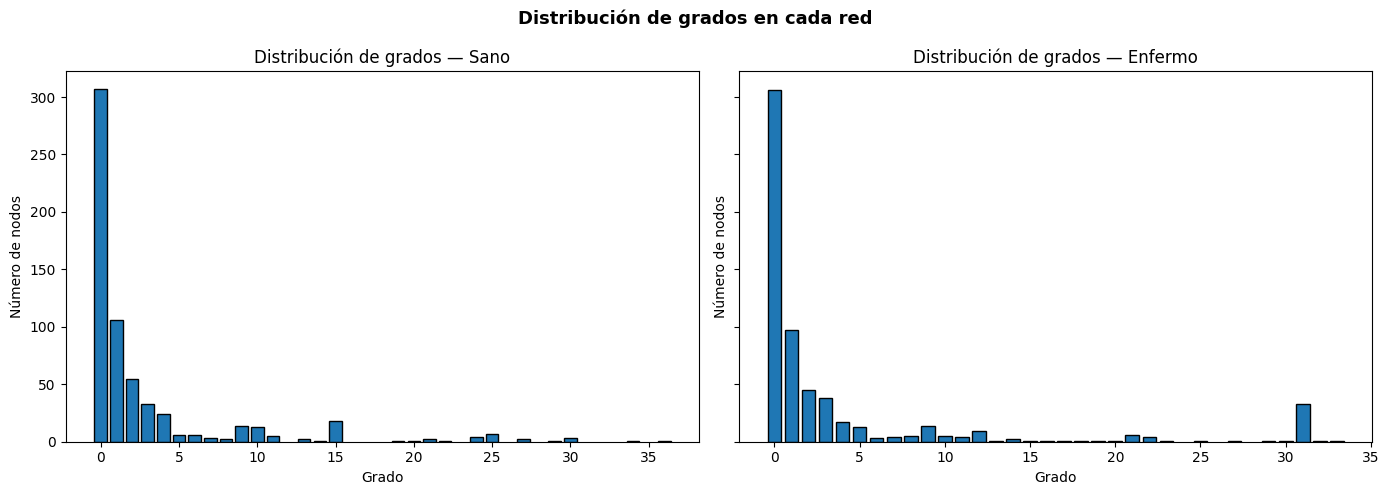

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, G, label in zip(axes, [G_healthy, G_disease], ["Sano", "Enfermo"]):
    degrees = [d for _, d in G.degree()]
    counts  = Counter(degrees)
    x = sorted(counts)
    y = [counts[k] for k in x]
    ax.bar(x, y, edgecolor="black")
    ax.set_xlabel("Grado")
    ax.set_ylabel("Número de nodos")
    ax.set_title(f"Distribución de grados — {label}")

plt.suptitle("Distribución de grados en cada red", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("degree_distribution.svg")
plt.show()

### 6.2 Red Diferencial

Aristas **ganadas** (verde) y **perdidas** (rojo discontinuo) al comparar la red enferma con la sana.

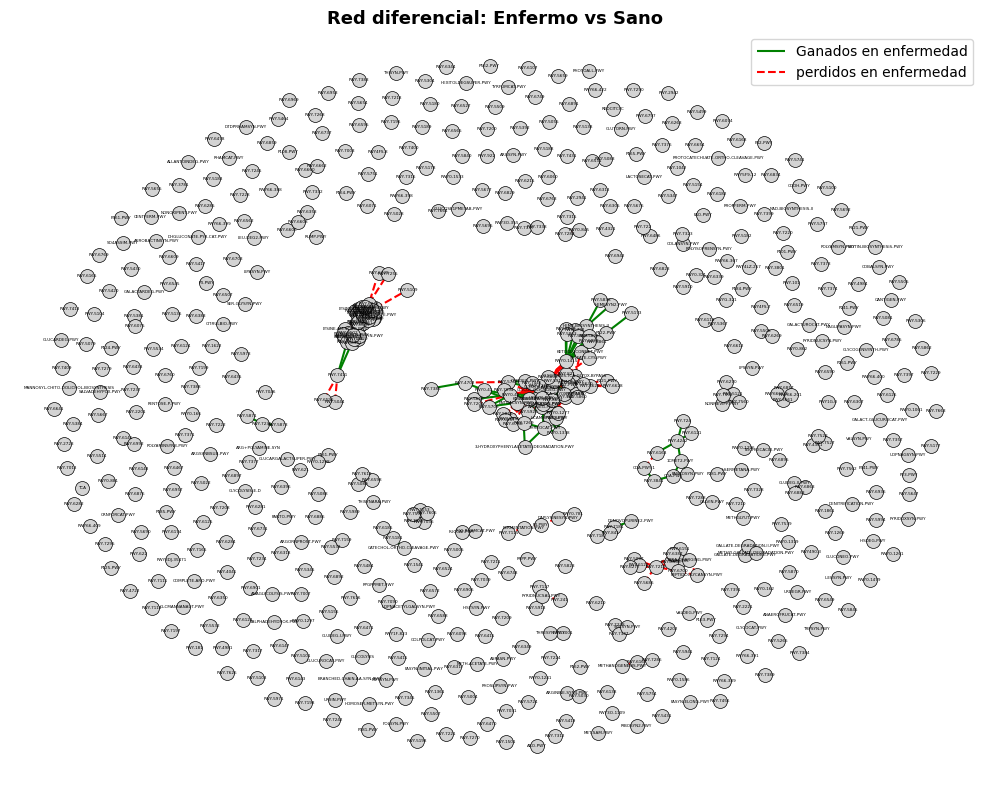

In [34]:
edges_healthy = {tuple(sorted(e)) for e in G_healthy.edges()}
edges_disease  = {tuple(sorted(e)) for e in G_disease.edges()}

gained_edges = edges_disease - edges_healthy
lost_edges   = edges_healthy - edges_disease

G_diff = nx.Graph()
G_diff.add_nodes_from(nodes)
G_diff.add_edges_from(gained_edges, change="ganados")
G_diff.add_edges_from(lost_edges,   change="perdidos")

pos = nx.spring_layout(G_diff, seed=42)

plt.figure(figsize=(10, 8))

nx.draw_networkx_nodes(G_diff, pos, node_size=100, node_color="lightgray", edgecolors="black", linewidths=0.5)
nx.draw_networkx_edges(G_diff, pos, edgelist=gained_edges, edge_color="green", width=1.5, label="Ganados en enfermedad")
nx.draw_networkx_edges(G_diff, pos, edgelist=lost_edges,   edge_color="red",   width=1.5, style="dashed", label="perdidos en enfermedad")
nx.draw_networkx_labels(G_diff, pos, font_size=3)

plt.title("Red diferencial: Enfermo vs Sano", fontsize=13, fontweight="bold")
plt.legend(fontsize=10)
plt.axis("off")
plt.tight_layout()
plt.savefig("differential_network.svg")
plt.show()

## 7. Pruebas Estadísticas

Comparación de las distribuciones de grado entre redes mediante pruebas no paramétricas:

| Test | Hipótesis nula |
|------|---------------|
| **Kolmogorov-Smirnov** | Ambas distribuciones son iguales |
| **Mann-Whitney U** | Los rangos de grado son iguales en ambas muestras |
| **Wilcoxon signed-rank** | La mediana del cambio de grado (Δk) es cero (prueba pareada) |

In [35]:
degree_df = pd.concat([
    pd.Series(dict(G_healthy.degree()), name="degree_healthy"),
    pd.Series(dict(G_disease.degree()),  name="degree_disease"),
], axis=1)
degree_df["delta_degree"] = degree_df["degree_disease"] - degree_df["degree_healthy"]
degree_df.to_csv("degree_comparison.csv")

k_healthy = degree_df["degree_healthy"].values
k_disease  = degree_df["degree_disease"].values
delta_k    = degree_df["delta_degree"].values

#pruebas estadisticas
ks = ks_2samp(k_healthy, k_disease)
mw = mannwhitneyu(k_healthy, k_disease, alternative="two-sided")

nonzero = delta_k[delta_k != 0]
wx = wilcoxon(nonzero, alternative="two-sided") if len(nonzero) > 0 else None

stats_results = pd.DataFrame({
    "Test":      ["Kolmogorov-Smirnov", "Mann-Whitney U", "Wilcoxon signed-rank"],
    "Statistic": [round(ks.statistic, 6), round(mw.statistic, 2), round(wx.statistic, 2) if wx else np.nan],
    "p-value":   [round(ks.pvalue, 6),    round(mw.pvalue, 6),    round(wx.pvalue, 6)    if wx else np.nan],
})
print(stats_results.to_string(index=False))

                Test     Statistic  p-value
  Kolmogorov-Smirnov      0.053312 0.342793
      Mann-Whitney U 187119.500000 0.447957
Wilcoxon signed-rank  10484.000000 0.258571


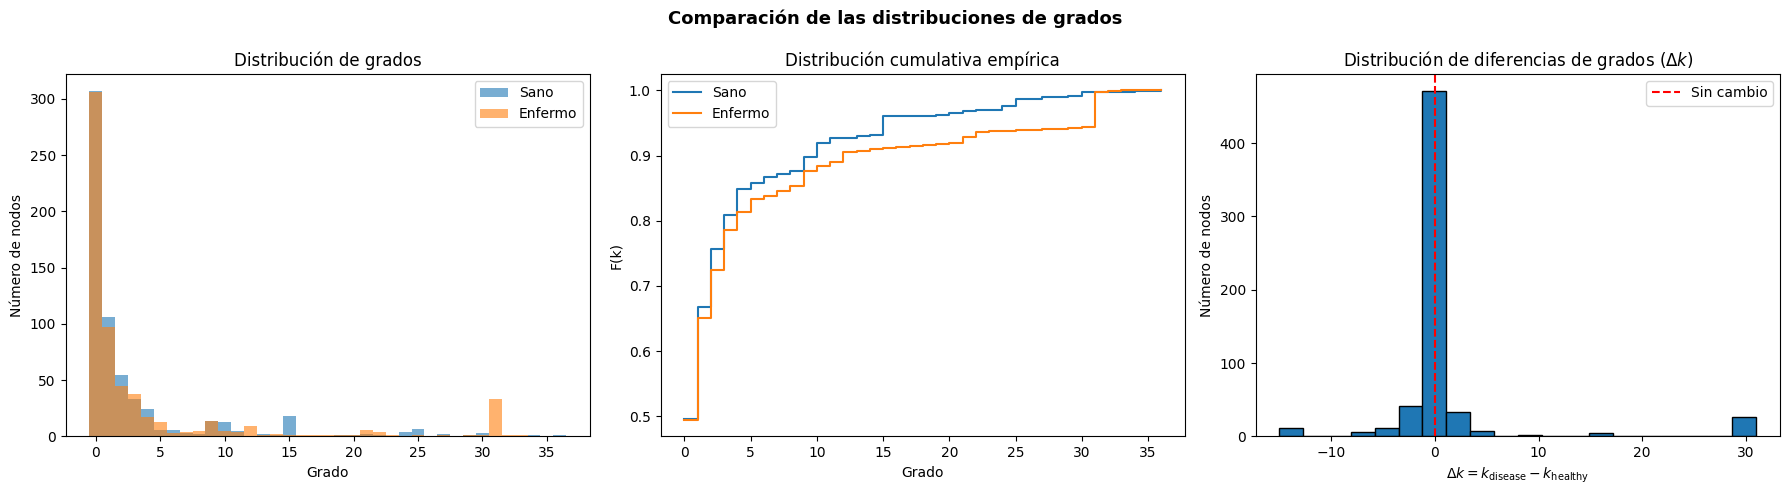

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Histograma grados
bins = range(
    min(k_healthy.min(), k_disease.min()),
    max(k_healthy.max(), k_disease.max()) + 2
)
axes[0].hist(k_healthy, bins=bins, alpha=0.6, label="Sano", align="left")
axes[0].hist(k_disease,  bins=bins, alpha=0.6, label="Enfermo",  align="left")
axes[0].set_xlabel("Grado")
axes[0].set_ylabel("Número de nodos")
axes[0].set_title("Distribución de grados")
axes[0].legend()

# CDF empirica
ecdf_h = ECDF(k_healthy)
ecdf_d = ECDF(k_disease)
x = np.arange(min(k_healthy.min(), k_disease.min()), max(k_healthy.max(), k_disease.max()) + 1)
axes[1].step(x, ecdf_h(x), where="post", label="Sano")
axes[1].step(x, ecdf_d(x), where="post", label="Enfermo")
axes[1].set_xlabel("Grado")
axes[1].set_ylabel("F(k)")
axes[1].set_title("Distribución cumulativa empírica")
axes[1].legend()

# Histograma de diferencia de grados
axes[2].hist(delta_k, bins=20, edgecolor="black")
axes[2].axvline(0, linestyle="--", color="red", label="Sin cambio")
axes[2].set_xlabel(r"$\Delta k = k_{\mathrm{disease}} - k_{\mathrm{healthy}}$")
axes[2].set_ylabel("Número de nodos")
axes[2].set_title(r"Distribución de diferencias de grados ($\Delta k$)")
axes[2].legend()

plt.suptitle("Comparación de las distribuciones de grados", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("degree_comparison.svg")
plt.show()

## 8. Prueba de Permutación

Se estima empíricamente la distribución nula de la **diferencia de grado promedio** (enfermo − sano) mediante 10,000 permutaciones aleatorias del pool combinado de grados.

Media de la diferencia (enfermos − sanos) observada : 1.0953
p-value (10,000 permutaciones)    : 0.0067


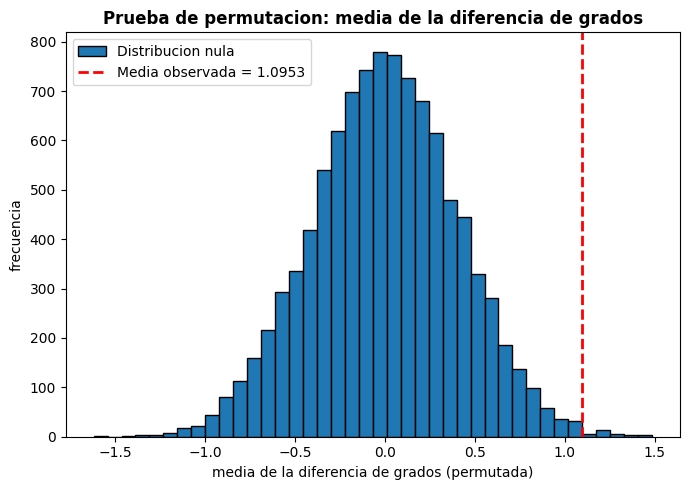

In [37]:
def permutation_test_mean_diff(x, y, n_perm=10_000, random_state=42):
    rng      = np.random.default_rng(random_state)
    observed = np.mean(y) - np.mean(x)
    pooled   = np.concatenate([x, y])
    n_x      = len(x)

    null = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(pooled)
        null[i] = np.mean(pooled[n_x:]) - np.mean(pooled[:n_x])

    p_value = np.mean(np.abs(null) >= np.abs(observed))
    return observed, p_value, null


observed_diff, p_perm, null_dist = permutation_test_mean_diff(k_healthy, k_disease)

print(f"Media de la diferencia (enfermos − sanos) observada : {observed_diff:.4f}")
print(f"p-value (10,000 permutaciones)    : {p_perm:.4f}")

plt.figure(figsize=(7, 5))
plt.hist(null_dist, bins=40, edgecolor="black", label="Distribucion nula")
plt.axvline(observed_diff, color="red", linestyle="--", linewidth=2,
            label=f"Media observada = {observed_diff:.4f}")
plt.xlabel("media de la diferencia de grados (permutada)")
plt.ylabel("frecuencia")
plt.title("Prueba de permutacion: media de la diferencia de grados", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("permutation_test.svg")
plt.show()

## 9. Prueba de Modelo de Configuración

La prueba de permutación original mezcla los vectores de grado de ambas redes, lo cual no respeta la restricción estructural de que la suma de grados en una red es fija. Para obtener una distribución nula más rigurosa, se emplea el **modelo de configuración**: se generan 10,000 pares de redes aleatorias que preservan **exactamente** las secuencias de grado de cada condición, pero con las conexiones redistribuidas al azar.


In [38]:


print(f"Suma de grados — sano   : {sum(k_healthy)}  ({'par' if sum(k_healthy) % 2 == 0 else 'impar'})")
print(f"Suma de grados — enfermo: {sum(k_disease)}  ({'par' if sum(k_disease) % 2 == 0 else 'impar'})")

observed_diff_cm = np.mean(k_disease) - np.mean(k_healthy)
print(f"\nDiferencia observada de grado promedio: {observed_diff_cm:.4f}")

#Distribución nula con configuration model
rng = np.random.default_rng(42)
N_PERM = 1000
null_cm = np.empty(N_PERM)

for i in range(N_PERM):
    R_sano    = nx.configuration_model(k_healthy,    seed=rng)
    R_enfermo = nx.configuration_model(k_disease, seed=rng)

    R_sano    = nx.Graph(R_sano)
    R_enfermo = nx.Graph(R_enfermo)
    R_sano.remove_edges_from(nx.selfloop_edges(R_sano))
    R_enfermo.remove_edges_from(nx.selfloop_edges(R_enfermo))

    mean_sano    = np.mean([d for _, d in R_sano.degree()])
    mean_enfermo = np.mean([d for _, d in R_enfermo.degree()])
    null_cm[i]   = mean_enfermo - mean_sano

p_cm = np.mean(np.abs(null_cm - null_cm.mean()) >= np.abs(observed_diff_cm - null_cm.mean()))

print(f"Media de la distribución nula        : {null_cm.mean():.4f}")
print(f"p-valor (modelo de configuración)    : {p_cm:.4f}")


## NOTA: hay que usar mas de 1000

Suma de grados — sano   : 1752  (par)
Suma de grados — enfermo: 2430  (par)

Diferencia observada de grado promedio: 1.0953
Media de la distribución nula        : 0.9444
p-valor (modelo de configuración)    : 0.0000


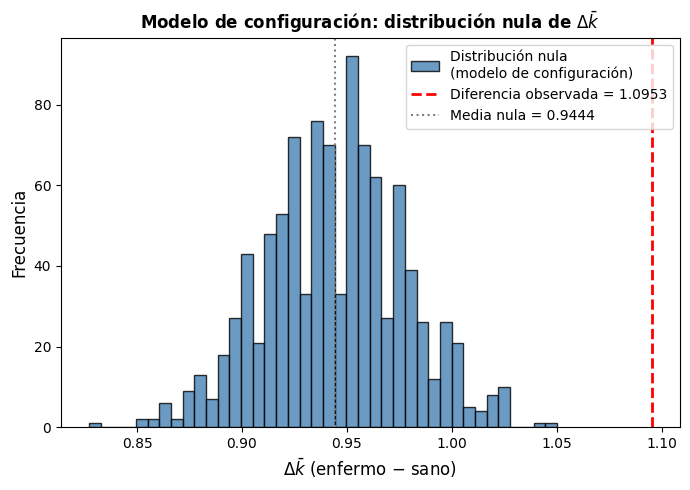

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(null_cm, bins=40, edgecolor="black", color="steelblue", alpha=0.8, label="Distribución nula\n(modelo de configuración)")
ax.axvline(observed_diff_cm, color="red", linestyle="--", linewidth=2,
           label=f"Diferencia observada = {observed_diff_cm:.4f}")
ax.axvline(null_cm.mean(), color="gray", linestyle=":", linewidth=1.5,
           label=f"Media nula = {null_cm.mean():.4f}")
ax.set_xlabel("$\\Delta\\bar{k}$ (enfermo $-$ sano)", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.set_title("Modelo de configuración: distribución nula de $\\Delta\\bar{k}$",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("configuration_model_test.svg")
plt.show()

## 10. Análisis Funcional

Se incorporan las anotaciones funcionales de las rutas metabólicas ( `Pathways_Types_complete.txt`) para evaluar si el cambio de conectividad observado entre condiciones se distribuye de forma homogénea entre categorías funcionales o si alguna categoría es consistentemente más o menos conectada en el estado de enfermedad.

El análisis comprende dos partes:

1. **Cambio de grado promedio por categoría** (∆k̄ por categoría): identifica qué tipos de rutas ganan o pierden conectividad en promedio.  
2. **Clasificación funcional de aristas ganadas, perdidas y conservadas**: cuantifica cuántas aristas de cada tipo involucran nodos de cada categoría.

In [40]:
#Cargar anotaciones funcionales
annot = pd.read_csv("Pathways_Types_complete.txt", sep="\t")
annot = annot.rename(columns={"Object-ID": "node"})
node_to_cat = dict(zip(annot["node"], annot["General_Pathway_Type"]))

delta_df = degree_change[["delta_degree"]].copy()
delta_df["categoria"] = delta_df.index.map(node_to_cat)

n_sin_anotacion = delta_df["categoria"].isna().sum()
print(f"Nodos sin anotación funcional: {n_sin_anotacion} de {len(delta_df)}")

delta_df = delta_df.dropna(subset=["categoria"])

#Resumen por categoría
cat_summary = (
    delta_df.groupby("categoria")["delta_degree"]
    .agg(media="mean", std="std", n="count", total="sum")
    .sort_values("media", ascending=False)
)
print("\nCambio de grado promedio por categoría funcional:")
cat_summary




Nodos sin anotación funcional: 13 de 619

Cambio de grado promedio por categoría funcional:


,media,std,n,total
categoria,,,,
Signaling and Regulation Metabolism,6.600000,13.667480,5,33
Carbohydrate metabolism,4.636364,11.255302,77,357
Specialized and Miscellaneous Routes,1.729167,7.775410,48,83
Cellular Structure and Modification of Macromolecules,1.687500,7.947484,16,27
Metabolism of Alcohols and Aldehydes,1.571429,4.613644,7,11
Biosynthesis of Cofactors and Vitamins,0.897727,5.793456,88,79
Nucleotide and Nucleic Acid Metabolism,0.777778,5.439288,45,35
Lipid metabolism,0.769231,9.557015,65,50
Metabolism of amino acids and derivatives,0.639535,6.861509,86,55


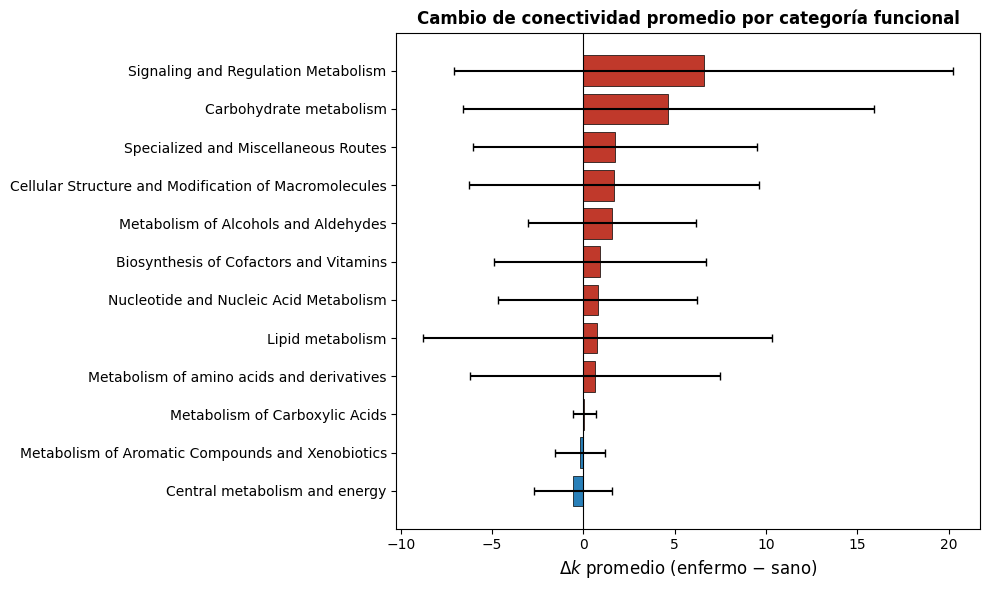

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#c0392b" if v > 0 else "#2980b9" for v in cat_summary["media"]]
ax.barh(
    cat_summary.index,
    cat_summary["media"],
    xerr=cat_summary["std"],
    color=colors,
    capsize=3,
    edgecolor="black",
    linewidth=0.5,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(r"$\Delta k$ promedio (enfermo $-$ sano)", fontsize=12)
ax.set_title("Cambio de conectividad promedio por categoría funcional", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("delta_k_por_categoria.svg")
plt.show()

In [42]:
#Clasificación funcional de aristas ganadas, perdidas y conservadas

records = []
nodos_list = list(nodes)  # orden fijo

Delta_np      = Delta.values
A_healthy_np  = A_healthy.values
A_disease_np  = A_disease.values
node_index    = {n: i for i, n in enumerate(nodos_list)}

for i in range(len(nodos_list)):
    for j in range(i + 1, len(nodos_list)):
        d = Delta_np[i, j]
        s = A_healthy_np[i, j]
        e = A_disease_np[i, j]
        if d == 0 and not (s == 1 and e == 1):
            continue
        tipo = "Ganada" if d == 1 else ("Perdida" if d == -1 else "Conservada")
        cat_i = node_to_cat.get(nodos_list[i], "Sin anotación")
        cat_j = node_to_cat.get(nodos_list[j], "Sin anotación")
        records.append({"tipo": tipo, "categoria": cat_i})
        records.append({"tipo": tipo, "categoria": cat_j})

edges_func_df = pd.DataFrame(records)

pivot = (
    edges_func_df[edges_func_df["categoria"] != "Sin anotación"]
    .groupby(["categoria", "tipo"])
    .size()
    .unstack(fill_value=0)
    [["Ganada", "Perdida", "Conservada"]]
)
pivot["Ratio G/P"] = (pivot["Ganada"] / pivot["Perdida"].replace(0, np.nan)).round(2)
pivot = pivot.sort_values("Ganada", ascending=False)

print("Menciones de categoría por tipo de arista:")
pivot.to_csv("aristas_por_categoria_funcional.csv")
pivot


Menciones de categoría por tipo de arista:


tipo,Ganada,Perdida,Conservada,Ratio G/P
categoria,,,,
Carbohydrate metabolism,407,50,56,8.14
Lipid metabolism,171,121,156,1.41
Biosynthesis of Cofactors and Vitamins,168,89,308,1.89
Metabolism of amino acids and derivatives,158,103,161,1.53
Specialized and Miscellaneous Routes,104,21,83,4.95
Nucleotide and Nucleic Acid Metabolism,67,32,75,2.09
Cellular Structure and Modification of Macromolecules,38,11,51,3.45
Signaling and Regulation Metabolism,33,0,3,NaN
Metabolism of Aromatic Compounds and Xenobiotics,25,38,75,0.66


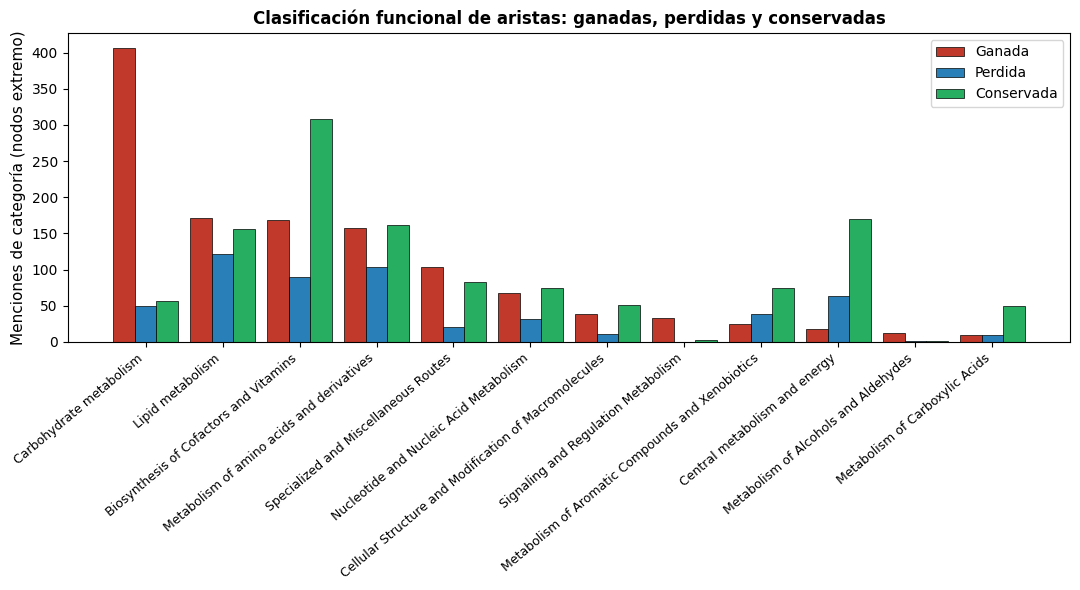

In [43]:

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(pivot))
width = 0.28

ax.bar(x - width, pivot["Ganada"],    width, label="Ganada",    color="#c0392b", edgecolor="black", linewidth=0.5)
ax.bar(x,         pivot["Perdida"],   width, label="Perdida",   color="#2980b9", edgecolor="black", linewidth=0.5)
ax.bar(x + width, pivot["Conservada"],width, label="Conservada",color="#27ae60", edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Menciones de categoría (nodos extremo)", fontsize=11)
ax.set_title("Clasificación funcional de aristas: ganadas, perdidas y conservadas",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("aristas_funcionales_por_categoria.svg")
plt.show()

## Referencias

- Jardim, V. C., Santos, S. D. S., Fujita, A., & Buckeridge, M. S. (2019). BioNetStat: a tool for biological networks differential analysis. Frontiers in genetics, 10, 594.
- Ideker, T., & Krogan, N. J. (2012). Differential network biology. Molecular systems biology, 8, 565.